In [89]:
import uproot
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [90]:
file = uproot.open("build/yz.root")

print(file.keys()) 
tree = file["yz"]
df = tree.arrays(library="pd")

['yz;1']


### STEP 1
Plottare tutte e quantità del file

In [91]:
custom_ranges = {
    'radius': None,
    'nbHits': None,
    'nbScoredHits': None,
    'y': None,
    'z': None,
    'Einc': (-0.02, 0.02),
    'Nuclear_dose': None,
    'Cytoplasmic_dose': None
}

cols_to_plot = ['radius', 'nbHits', 'nbScoredHits', 'y', 'z', 'Einc','Nuclear_dose', 'Cytoplasmic_dose']

units = {
    'radius': ' [nm]',
    'nbHits': '',
    'nbScoredHits': '',
    'y': ' [keV/um]',
    'z': ' [Gy]',
    'Einc': ' [MeV]',
    'Nuclear_dose' : '[Gy]',
    'Cytoplasmic_dose': '[Gy]'
} # Controlla se sto facendo bene...!

count = len(df)
# Senza [1:], includi TUTTI gli indici trovati
counts = df['nbScoredHits'].value_counts().sort_index()

n_zeros = (df['nbScoredHits'] == 0).sum()
print(f"Number of events with nbEdep = 0: {n_zeros}")

for i, count in counts.items():
    print(f"Number of events with nbEdep = {int(i)}: {int(count)}")

# Somma totale di tutto quello che hai trovato
print(f"Total of number of Event = {counts.sum()}")

Number of events with nbEdep = 0: 0
Number of events with nbEdep = 1: 1594
Number of events with nbEdep = 2: 1109
Number of events with nbEdep = 3: 1202
Number of events with nbEdep = 4: 1318
Number of events with nbEdep = 5: 1215
Number of events with nbEdep = 6: 1203
Number of events with nbEdep = 7: 1121
Number of events with nbEdep = 8: 1088
Number of events with nbEdep = 9: 1040
Number of events with nbEdep = 10: 1044
Number of events with nbEdep = 11: 1192
Number of events with nbEdep = 12: 962
Number of events with nbEdep = 13: 804
Number of events with nbEdep = 14: 687
Number of events with nbEdep = 15: 676
Number of events with nbEdep = 16: 664
Number of events with nbEdep = 17: 580
Number of events with nbEdep = 18: 530
Number of events with nbEdep = 19: 451
Number of events with nbEdep = 20: 430
Number of events with nbEdep = 21: 375
Number of events with nbEdep = 22: 366
Number of events with nbEdep = 23: 325
Number of events with nbEdep = 24: 305
Number of events with nbEd

 Istogramma radius ha un range impostato a: None
 Istogramma nbHits ha un range impostato a: None
 Istogramma nbScoredHits ha un range impostato a: None
 Istogramma y ha un range impostato a: None
 Istogramma z ha un range impostato a: None
 Istogramma Einc ha un range impostato a: (-0.02, 0.02)
 Istogramma Nuclear_dose ha un range impostato a: None
 Istogramma Cytoplasmic_dose ha un range impostato a: None


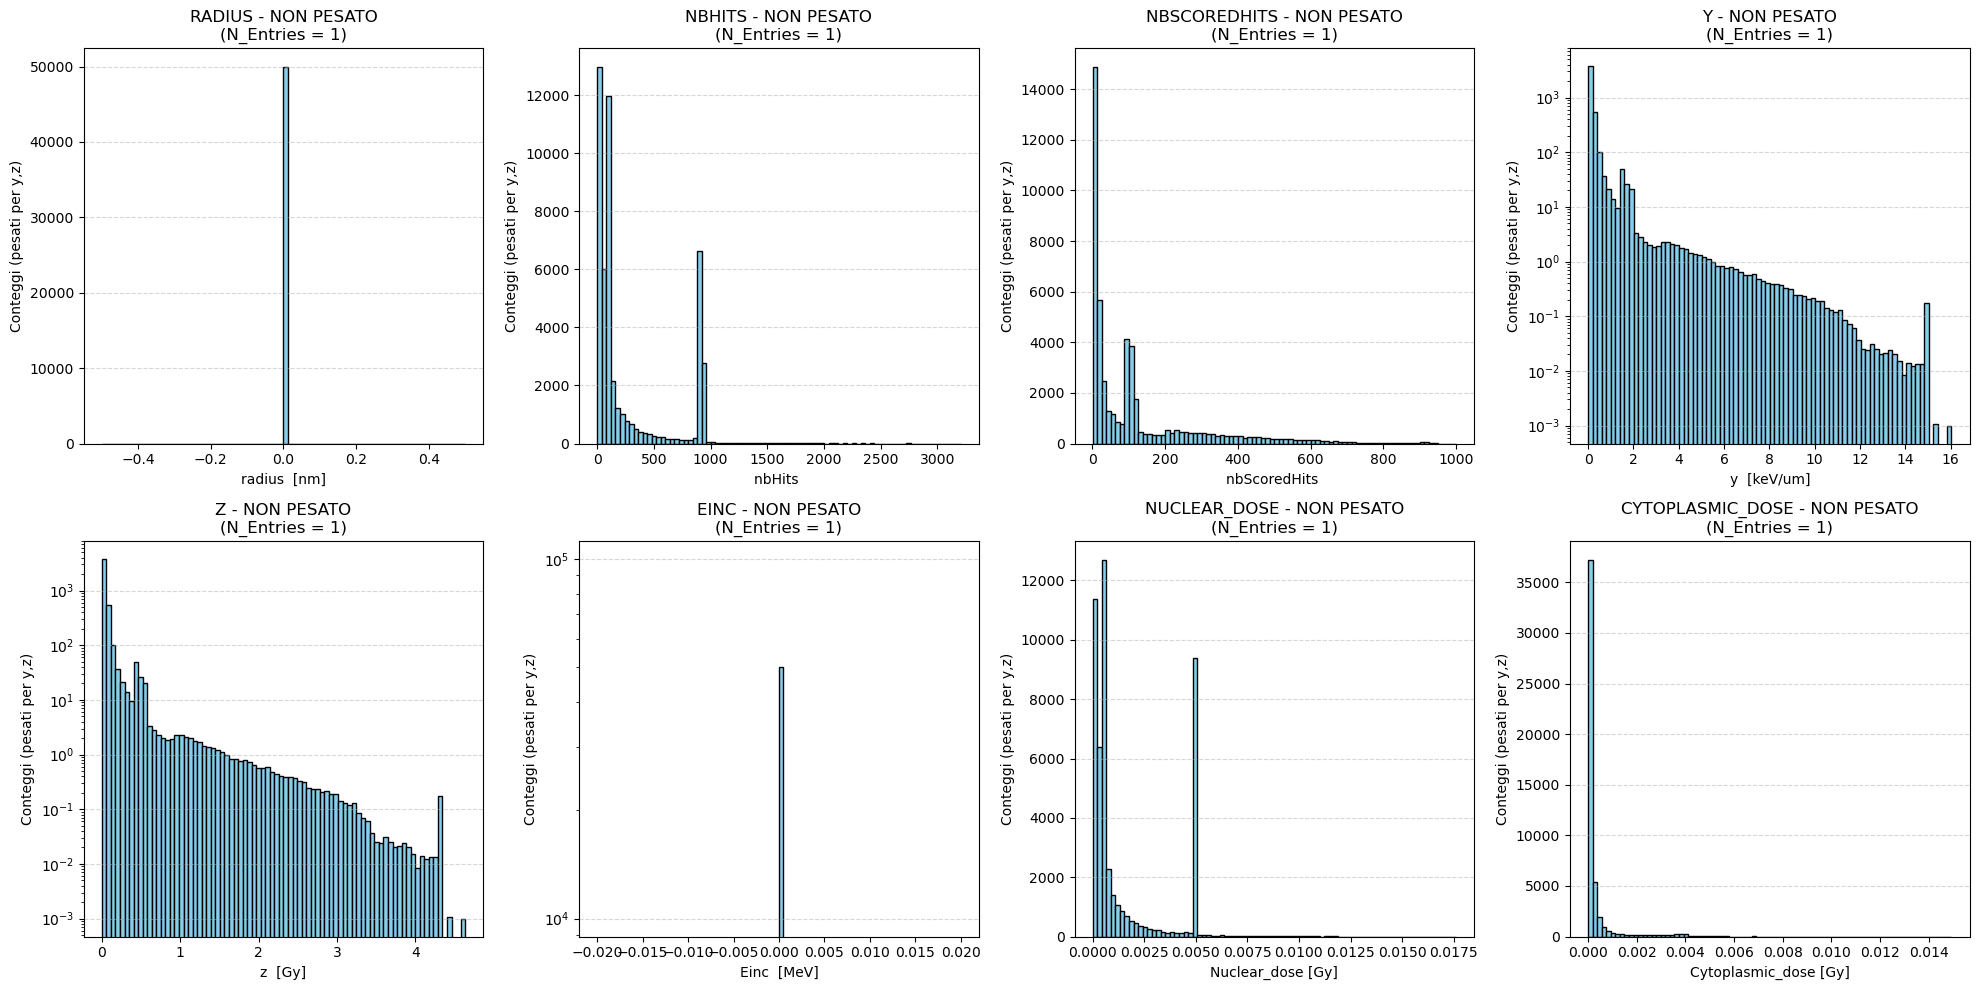

In [92]:
import matplotlib.pyplot as plt
import numpy as np

# 1. CALCOLO PESI (Una sola volta)
# Se nbScoredHits è > 0, il peso è 1/nbScoredHits, altrimenti è 0
df['weight'] = 1.0 / df['nbScoredHits']

# 2. DEFINIZIONE DELLE COLONNE E RANGE (Puoi personalizzare i range qui)
cols_to_plot = ['radius', 'nbHits', 'nbScoredHits', 'y', 'z', 'Einc', 'Nuclear_dose', 'Cytoplasmic_dose']

# 3. PLOTTING
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    current_range = custom_ranges.get(col)
    print(f" Istogramma {col} ha un range impostato a: {current_range}")
    # Applichiamo il peso SOLO se la colonna è 'y' o 'z'
    current_weights = df['weight'] if col in ['y', 'z'] else None
    
    # Decidiamo la scala logaritmica (opzionale, basato sui tuoi dati)
    is_log = col in ['y', 'z', 'Einc']
    
    # Plot dell'istogramma
    axes[i].hist(df[col], bins=80, range=custom_ranges.get(col), 
                 color='skyblue', edgecolor='black', log=is_log, 
                 weights=current_weights)
    
    axes[i].set_title(f'{col.upper()} - NON PESATO\n(N_Entries = {count})')
    axes[i].set_xlabel(f'{col} {units.get(col, "")}')
    axes[i].set_ylabel('Conteggi (pesati per y,z)')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

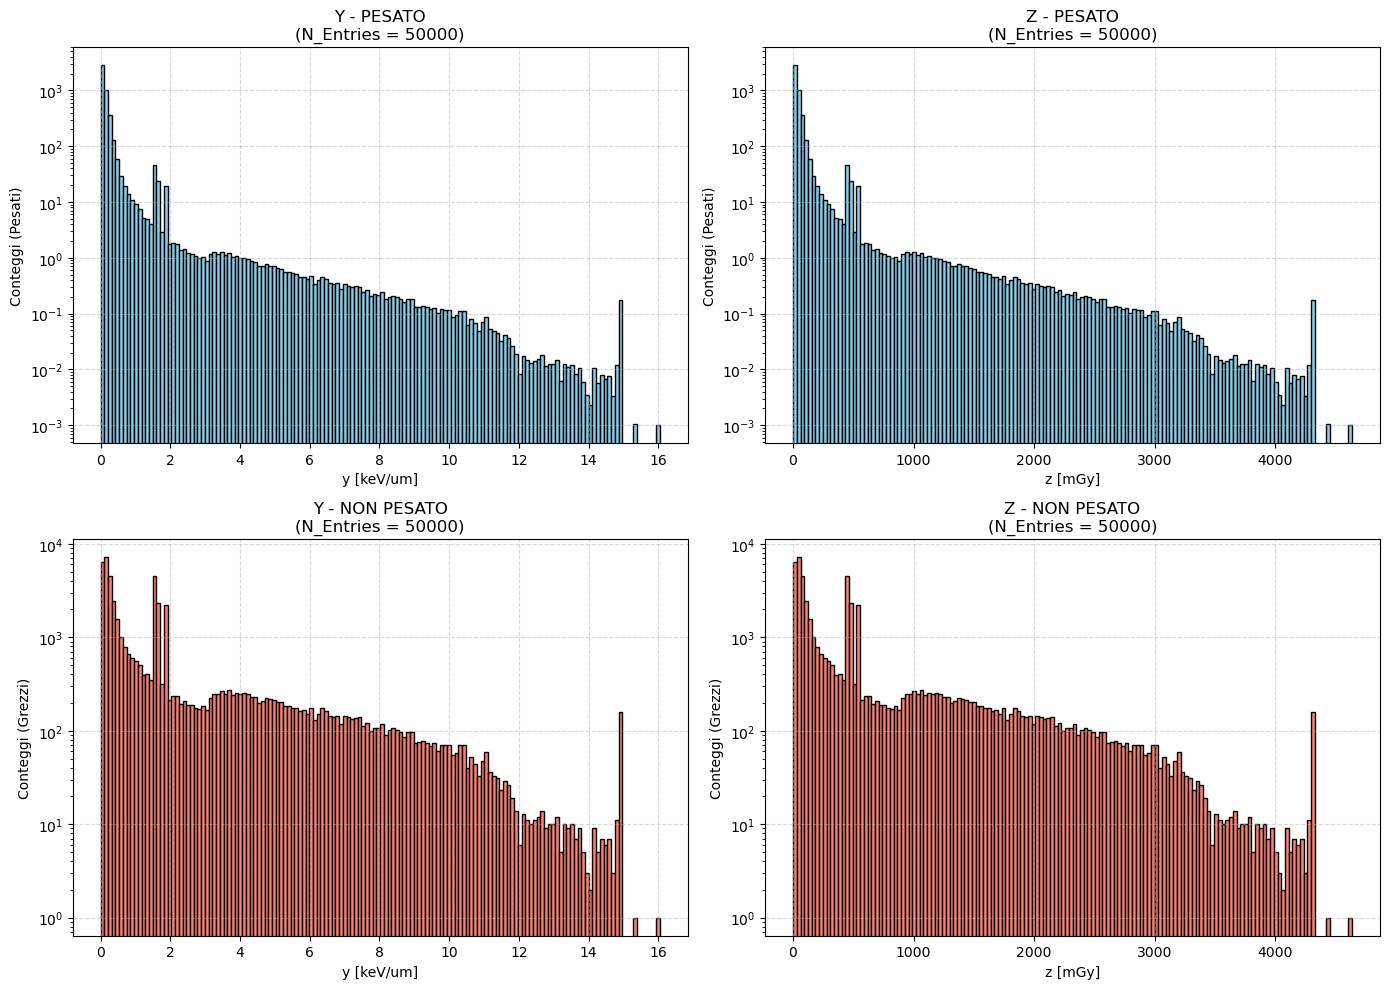

In [93]:
import matplotlib.pyplot as plt
import numpy as np

# Fattori di conversione
scales = {'y': 1.0, 'z': 1000.0}
units_label = {'y': 'keV/um', 'z': 'mGy'}

# Creiamo la figura
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

# Definiamo le colonne
cols = ['y', 'z']

for i, col in enumerate(cols):
    data = df[col] * scales[col]
    
    # Calcolo conteggi
    # Per il non pesato: numero puro di eventi
    count = len(df)
    
    # 1. GRAFICO PESATO
    axes[0, i].hist(data, bins=150, range=None, weights=df['weight'], 
                    color='skyblue', edgecolor='black', log=True)
    axes[0, i].set_title(f'{col.upper()} - PESATO\n(N_Entries = {count:.0f})')
    axes[0, i].set_ylabel('Conteggi (Pesati)')
    axes[0, i].set_xlabel(f'{col} [{units_label[col]}]')
    axes[0, i].grid(linestyle='--', alpha=0.5)

    # 2. GRAFICO NON PESATO
    axes[1, i].hist(data, bins=150, range=None, weights=None, 
                    color='salmon', edgecolor='black', log=True)
    axes[1, i].set_title(f'{col.upper()} - NON PESATO\n(N_Entries = {count})')
    axes[1, i].set_ylabel('Conteggi (Grezzi)')
    axes[1, i].set_xlabel(f'{col} [{units_label[col]}]')
    axes[1, i].grid(linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [94]:
df['y'].head(), df['z'].head(), df['nbScoredHits'].head()

(0    1.154233
 1    0.242405
 2    0.254189
 3    0.293608
 4    0.253004
 Name: y, dtype: float64,
 0    0.333699
 1    0.070081
 2    0.073488
 3    0.084885
 4    0.073146
 Name: z, dtype: float64,
 0    72.0
 1    15.0
 2    16.0
 3    16.0
 4    12.0
 Name: nbScoredHits, dtype: float64)

In [95]:
# Andiamo a creare y_data e z_data che sono array di y e z originali pesati su nbScoredHits.
df_pesi['weight'] = 1/df['nbScoredHits']
df_pesi['weight'].head()

0    0.013889
1    0.066667
2    0.062500
3    0.062500
4    0.083333
Name: weight, dtype: float64

In [96]:
somma_pesi = df_pesi['weight'].sum()

### Step 3
Intera pipeline dalle quantità microdosimetriche a MKM e LQ model.

In [97]:
R_d = 0.420       # Raggio del dominio (420 nm -> 0.420 um)
R_n = 4.0         # Raggio del nucleo cellulare (4.0 um)
y0 = 150.0        # Parametro di saturazione MKM [keV/um]
alpha_0 = 0.147   # Radiosensibilità lineare [Gy^-1]
beta_cell = 0.02  # Coefficiente quadratico [Gy^-2]
rho = 10 ** (-15) # Densità acqua in kg/um^3
k_energetico = 1.602 * 10 **(-16) # Per passare da keV a Joule

# Costante di conversione microdosimetrica sferica: passo da keV/um a Gy
k_conv = k_energetico / (rho * np.pi * (R_d**2))

In [98]:
y_f = (df['y']*df_pesi['weight']).sum() / df_pesi['weight'].sum()
y_d = ((df['y']**2) * df_pesi['weight']).sum() / (df['y'] * df_pesi['weight']).sum()

# Calcolo di y* (energia lineare media pesata in dose satura per il MKM)
y_numerator = np.sum(df_pesi['weight'] * (df['y']**2) * (1.0 - np.exp(-(df['y']**2) / (y0**2))))
y_denominator = np.sum(df['y'] * df_pesi['weight'])
y_star = y_numerator / y_denominator
# Calcolo dell'Alpha cellulare effettivo secondo il modello MKM
alpha_cell = alpha_0 + (beta_cell * k_conv * y_star)

print("\n--- DIAGNOSTICA PARAMETRI FISICI ---")
print(f"y_F (Frequency-mean): {y_f:.4f} keV/um")
print(f"y_D (Dose-mean):      {y_d:.4f} keV/um")
print(f"y* (Satura MKM):      {y_star:.4f} keV/um")
print(f"Alpha Cell (MKM):     {alpha_cell:.4f} Gy^-1")
print(f"Dose media per singolo hit (z_F): {df['z'].mean():.4f} Gy")
print("------------------------------------\n")


--- DIAGNOSTICA PARAMETRI FISICI ---
y_F (Frequency-mean): 0.1891 keV/um
y_D (Dose-mean):      1.8818 keV/um
y* (Satura MKM):      0.0038 keV/um
Alpha Cell (MKM):     0.1470 Gy^-1
Dose media per singolo hit (z_F): 0.5888 Gy
------------------------------------



In [99]:
alfa_cell = alpha_0 + (beta_cell* k_energetico * y_star)/(np.pi* rho *R_d*R_d)
D_nucleo = df['Nuclear_dose'].sum()
meno_lnS = alfa_cell*D_nucleo + beta_cell*D_nucleo*D_nucleo

In [100]:
casi_decadimenti = np.linspace(0, 20000, 100) 

risultati_sopravvivenza = []
dosi_medie_nucleo = []
rbe_lista = []

std_sopravvivenza = []
std_rbe = []

n_sim = 300
print("Numero di isotopi decaduti:\n")
for N in casi_decadimenti:
    print(f"Isotopi decaduti: {N}")
    S_temp = []
    D_temp = []
    rbe_temp = []

    for _ in range(n_sim):
        # Creo pesi correlati alla colonna y
        df_sample = df[['y', 'nbScoredHits']].sample(n=int(N), replace=True)
        # Creo un altro df per semplicità
        df_sample['weight'] = 1/df_sample['nbScoredHits']

        # y_star che dipende da N
        y_numerator = np.sum((df_sample['y']* df_sample['weight'] **2) * (1 - np.exp(-(df_sample['y']**2) / (y0**2))))
        y_denominator = np.sum(df_sample['y'] * df_sample['weight'])
        y_star = y_numerator / y_denominator

        # Dose nucleare sommativa sul paniere in base a N
        df_sample_Nuclear_dose = df['Nuclear_dose'].sample(int(N), replace=True)
        D_nucleo = df_sample_Nuclear_dose.sum()

        alpha_cell = alpha_0 + (beta_cell* k_energetico *y_star)/(np.pi* rho *R_d*R_d)
        S = np.exp(-alpha_cell * D_nucleo - beta_cell * (D_nucleo**2))

        rbe = (np.sqrt(alpha_0**2 + 4 * beta_cell * (alpha_cell * D_nucleo + beta_cell * (D_nucleo**2))) - alpha_0) / (2 * beta_cell * D_nucleo)

        S_temp.append(S)
        D_temp.append(D_nucleo)
        rbe_temp.append(rbe)

        # Salvataggio medie e deviazioni standard
    risultati_sopravvivenza.append(np.mean(S_temp))
    dosi_medie_nucleo.append(np.mean(D_temp))
    rbe_lista.append(np.mean(rbe_temp))

    std_sopravvivenza.append(np.std(S_temp))
    std_rbe.append(np.std(rbe_temp))

Numero di isotopi decaduti:

Isotopi decaduti: 0.0
Isotopi decaduti: 202.02020202020202

/tmp/ipykernel_2176/2114413310.py:27: RuntimeWarning: invalid value encountered in scalar divide
  y_star = y_numerator / y_denominator



Isotopi decaduti: 404.04040404040404
Isotopi decaduti: 606.060606060606
Isotopi decaduti: 808.0808080808081
Isotopi decaduti: 1010.1010101010102
Isotopi decaduti: 1212.121212121212
Isotopi decaduti: 1414.141414141414
Isotopi decaduti: 1616.1616161616162
Isotopi decaduti: 1818.1818181818182
Isotopi decaduti: 2020.2020202020203
Isotopi decaduti: 2222.222222222222
Isotopi decaduti: 2424.242424242424
Isotopi decaduti: 2626.2626262626263
Isotopi decaduti: 2828.282828282828
Isotopi decaduti: 3030.3030303030305
Isotopi decaduti: 3232.3232323232323
Isotopi decaduti: 3434.343434343434
Isotopi decaduti: 3636.3636363636365
Isotopi decaduti: 3838.3838383838383
Isotopi decaduti: 4040.4040404040406
Isotopi decaduti: 4242.424242424242
Isotopi decaduti: 4444.444444444444
Isotopi decaduti: 4646.464646464647
Isotopi decaduti: 4848.484848484848
Isotopi decaduti: 5050.50505050505
Isotopi decaduti: 5252.525252525253
Isotopi decaduti: 5454.545454545455
Isotopi decaduti: 5656.565656565656
Isotopi decaduti: 

Questa parte è fatta da Gemini perché puramente grafica

In [101]:
# =====================================================================
# BLOCCO COMPLEMENTARE DI ANALISI BIOLOGICA (D_10 ed RBE_10) - CORRETTO
# =====================================================================

log_S = np.log(np.array(risultati_sopravvivenza))
target_log_S = np.log(0.10)

# Poiché S diminuisce all'aumentare dei decadimenti, log_S è decrescente.
# Per np.interp invertiamo l'asse cercando la corrispondenza corretta:
# Visto che np.interp(x, xp, fp) vuole xp crescente, ordiniamo le coppie in base a log_S crescente.
sort_idx = np.argsort(log_S)
log_S_sorted = log_S[sort_idx]
casi_sorted = casi_decadimenti[sort_idx]
dosi_sorted = np.array(dosi_medie_nucleo)[sort_idx]

# 1. Trova quanti decadimenti servono per arrivare alla soglia del 10% (S = 0.10)
decadimenti_soglia = np.interp(target_log_S, log_S_sorted, casi_sorted)

# 2. Trova la dose reale assorbita dal nucleo in corrispondenza di quel punto
dose_soglia_sim = np.interp(target_log_S, log_S_sorted, dosi_sorted)

# 3. Calcola la dose teorica di riferimento (X-ray a basso LET) usando la formula risolutiva LQ
dose_soglia_ref = (-alpha_0 + np.sqrt(alpha_0**2 - 4 * beta_cell * np.log(0.10))) / (2 * beta_cell)

# 4. Calcola l'RBE effettivo alla soglia terapeutica del 10%
rbe_al_10 = dose_soglia_ref / dose_soglia_sim

# Stampa diagnostica dei risultati clinici sulla console
print("\n" + "="*45)
print("       Risultati con soglia di dose D10 (Corretto)")
print("="*45)
print(f"Decadimenti necessari (N_10):   {decadimenti_soglia:.1f} isotopi")
print(f"Dose Nucleo simulata (D_10):   {dose_soglia_sim:.4f} Gy")
print(f"Dose Riferimento (X-Ray):      {dose_soglia_ref:.4f} Gy")
print(f"RBE effettivo al 10%:          {rbe_al_10:.3f}")
print("="*45 + "\n")


       Risultati con soglia di dose D10 (Corretto)
Decadimenti necessari (N_10):   4981.4 isotopi
Dose Nucleo simulata (D_10):   7.6693 Gy
Dose Riferimento (X-Ray):      7.6667 Gy
RBE effettivo al 10%:          1.000



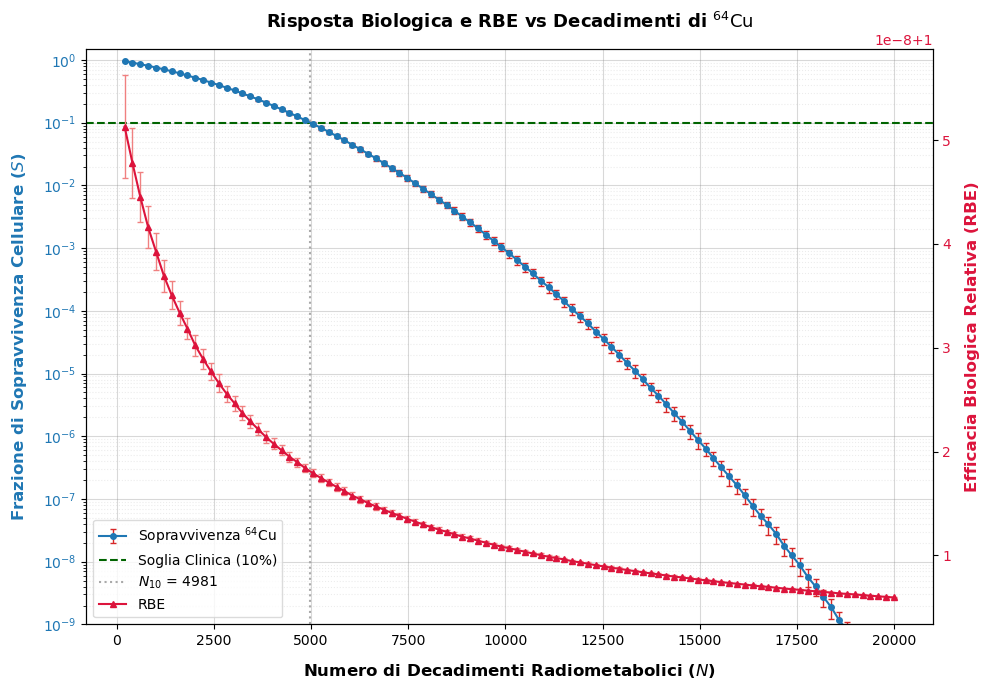

In [102]:
# =====================================================================
# BLOCCO GRAFICO COMBINATO: SOPRAVVIVENZA (Asse Y Sinistro) E RBE (Asse Y Destro)
# =====================================================================
fig, ax1 = plt.subplots(figsize=(10, 7), dpi=100)

# --- ASSE Y 1: Frazione di Sopravvivenza (S) ---
color_s = "#1f77b4"
ax1.set_xlabel(
    "Numero di Decadimenti Radiometabolici ($N$)", fontsize=12, fontweight="bold", labelpad=10
)
ax1.set_ylabel(
    "Frazione di Sopravvivenza Cellulare ($S$)",
    color=color_s,
    fontsize=12,
    fontweight="bold",
    labelpad=10,
)
line1 = ax1.errorbar(
    casi_decadimenti,
    risultati_sopravvivenza,
    yerr=std_sopravvivenza,
    fmt="-o",
    markersize=4,
    color=color_s,
    ecolor="#d62728",
    elinewidth=1,
    capsize=2,
    label=r"Sopravvivenza $^{64}$Cu (MKM-LQ)",
)
ax1.set_yscale("log")
ax1.set_ylim(1e-9, 1.5)
ax1.tick_params(axis="y", labelcolor=color_s)
ax1.grid(True, which="major", color="gray", linestyle="-", alpha=0.3)
ax1.grid(True, which="minor", color="gray", linestyle=":", alpha=0.15)

# Linee di soglia clinica sul primo asse
line2 = ax1.axhline(
    y=0.10,
    color="darkgreen",
    linestyle="--",
    linewidth=1.5,
    label="Soglia Clinica (10%)",
)
line3 = ax1.axvline(
    x=decadimenti_soglia,
    color="darkgray",
    linestyle=":",
    linewidth=1.5,
    label=f"$N_{{10}}$ = {int(decadimenti_soglia)} decadimenti",
)

# --- ASSE Y 2: RBE (Condivide lo stesso asse X) ---
ax2 = ax1.twinx()
color_rbe = "crimson"
ax2.set_ylabel(
    "Efficacia Biologica Relativa (RBE)",
    color=color_rbe,
    fontsize=12,
    fontweight="bold",
    labelpad=10,
)
line4 = ax2.errorbar(
    casi_decadimenti,
    rbe_lista,
    yerr=std_rbe,
    fmt="-^",
    markersize=4,
    color=color_rbe,
    ecolor="lightcoral",
    elinewidth=1,
    capsize=2,
    label="RBE Medio",
)
ax2.tick_params(axis="y", labelcolor=color_rbe)
# Rimuoviamo la griglia del secondo asse per evitare sovrapposizioni caotiche
ax2.grid(False)

# --- Titolo e Legenda Unificata ---
plt.title(
    r"Risposta Biologica e RBE vs Decadimenti di $^{64}\text{Cu}$",
    fontsize=13,
    fontweight="bold",
    pad=15,
)

# Uniamo le legende dei due assi in un unico box chiaro
lines = [line1, line2, line3, line4]
labels = [l.get_label() if hasattr(l, "get_label") else l.get_label() for l in lines]
# Per gestire correttamente l'oggetto errorbar nella legenda:
ax1.legend(
    [line1, line2, line3, line4[0]],
    [
        r"Sopravvivenza $^{64}$Cu",
        "Soglia Clinica (10%)",
        f"$N_{{10}}$ = {int(decadimenti_soglia)}",
        "RBE",
    ],
    loc="lower left",
    fontsize=10,
    frameon=True,
    facecolor="white",
    edgecolor="lightgray",
)

plt.tight_layout()
plt.show()